# Metals Flow-Filtered Residual Reversion

Full 12-month core metals test for `GC`, `SI`, `HG`, `PL`, `PA`; `ALI` is isolated as a diagnostic asset.

Strategy logic: no-lookahead EWMA relative-value residuals, gated by EWMA Mahalanobis flow anomaly and large-minus-small flow disagreement. Positions exit when residuals converge toward zero.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

OUT = Path("../../experiments/HYP-0013-metals-flow-filtered-residual-reversion").resolve()
results = json.loads((OUT / "results.json").read_text())
summary = results["summary"]
summary.keys()

dict_keys(['ali_diagnostics', 'bootstrap', 'core_roots', 'cost_estimates', 'cost_variants', 'end', 'fdr_significant_tests', 'feature_correlations_with_md', 'filter_pass_rate', 'isolated_roots', 'large_small_l1_threshold', 'md_threshold', 'mean_core_contribution', 'monthly_ic_summary', 'monthly_net_positive_fraction', 'periods_per_year', 'primary_complete_bars', 'residual_z_abs_mean', 'roots', 'selected_strategy_metrics', 'split_metrics', 'start', 'threshold_summary', 'top_information_coefficients', 'trade_inventory'])

## Coverage And Dollar Bars

In [2]:
pd.read_csv(OUT / "trade_inventory.csv")

,root,trades,start_ts,end_ts,notional,signed_ratio,median_trade_notional,p99_trade_notional
0,GC,32877317,2025-06-22 22:00:00+00:00,2026-06-21 23:59:56.082051+00:00,2.065979e+13,-0.001818,455310.0,2703760.00
1,SI,12785778,2025-06-22 22:00:00+00:00,2026-06-21 23:59:52.143142+00:00,6.037590e+12,-0.000973,379400.0,2088355.75
2,HG,6560711,2025-06-22 22:00:00+00:00,2026-06-21 23:59:56.506287+00:00,1.454904e+12,-0.006351,148800.0,1024362.50
3,PL,5130344,2025-06-22 22:00:00+00:00,2026-06-21 23:58:25.144921+00:00,6.236100e+11,0.001034,97320.0,502250.00
4,PA,1028619,2025-06-22 22:00:00+00:00,2026-06-21 23:55:48.277942+00:00,2.106286e+11,-0.004751,156100.0,768500.00
5,ALI,112563,2025-06-23 00:10:43.178975+00:00,2026-06-21 23:50:52.149488+00:00,1.975728e+10,0.006048,81512.5,750437.50


In [3]:
pd.read_csv(OUT / "threshold_summary.csv")

,threshold,threshold_m,bars,bars_per_day,median_duration_seconds,mean_duration_seconds,median_trades,mean_trades,median_dominant_share,mean_hhi
0,1.000000e+08,100.0,288059,791.191406,46.165866,108.908184,201.0,202.676195,0.745119,0.610560
1,2.500000e+08,250.0,115649,317.644878,120.353400,271.704090,500.0,504.826708,0.738176,0.598147
2,5.000000e+08,500.0,57897,159.025204,248.224812,543.021316,1000.0,1008.374216,0.734434,0.591409
3,1.000000e+09,1000.0,28967,79.565238,509.396932,1085.475294,1999.0,2015.435427,0.732529,0.586121


In [4]:
pd.DataFrame(summary["cost_estimates"])

,median_spread_bps,median_top_depth,p75_spread_bps,per_side_cost_bps,root,rows,source
0,1.101576,3.0,1.380326,0.550788,GC,41124344,mbp1
1,3.739017,3.0,4.665630,1.869508,SI,23412610,mbp1
2,1.600768,4.0,2.384453,0.800384,HG,14503067,mbp1
3,5.126365,3.0,6.613160,2.563182,PL,16496932,mbp1
4,11.187768,5.0,12.332991,5.593884,PA,2584537,mbp1


## Strategy Performance

In [5]:
pd.read_csv(OUT / "variants.csv")

,variant,cost_multiplier,observations,active_bars,gross_return,cost_return,net_return,mean_net_bps,tstat,annualized_sharpe,hit_rate,max_drawdown,gross_to_cost,turnover
0,cost_0.0,0.0,115649,16113,1.702271,0.000000,1.702271,0.147193,5.971202,5.980767,0.071786,-0.068134,inf,673.208333
1,cost_1.0,1.0,115649,16113,1.702271,0.156114,1.546157,0.133694,5.436051,5.444759,0.071648,-0.069836,10.904042,673.208333
2,cost_2.0,2.0,115649,16113,1.702271,0.312228,1.390044,0.120195,4.896216,4.904059,0.071475,-0.071538,5.452021,673.208333
3,cost_3.0,3.0,115649,16113,1.702271,0.468341,1.233930,0.106696,4.352394,4.359366,0.071328,-0.073240,3.634681,673.208333


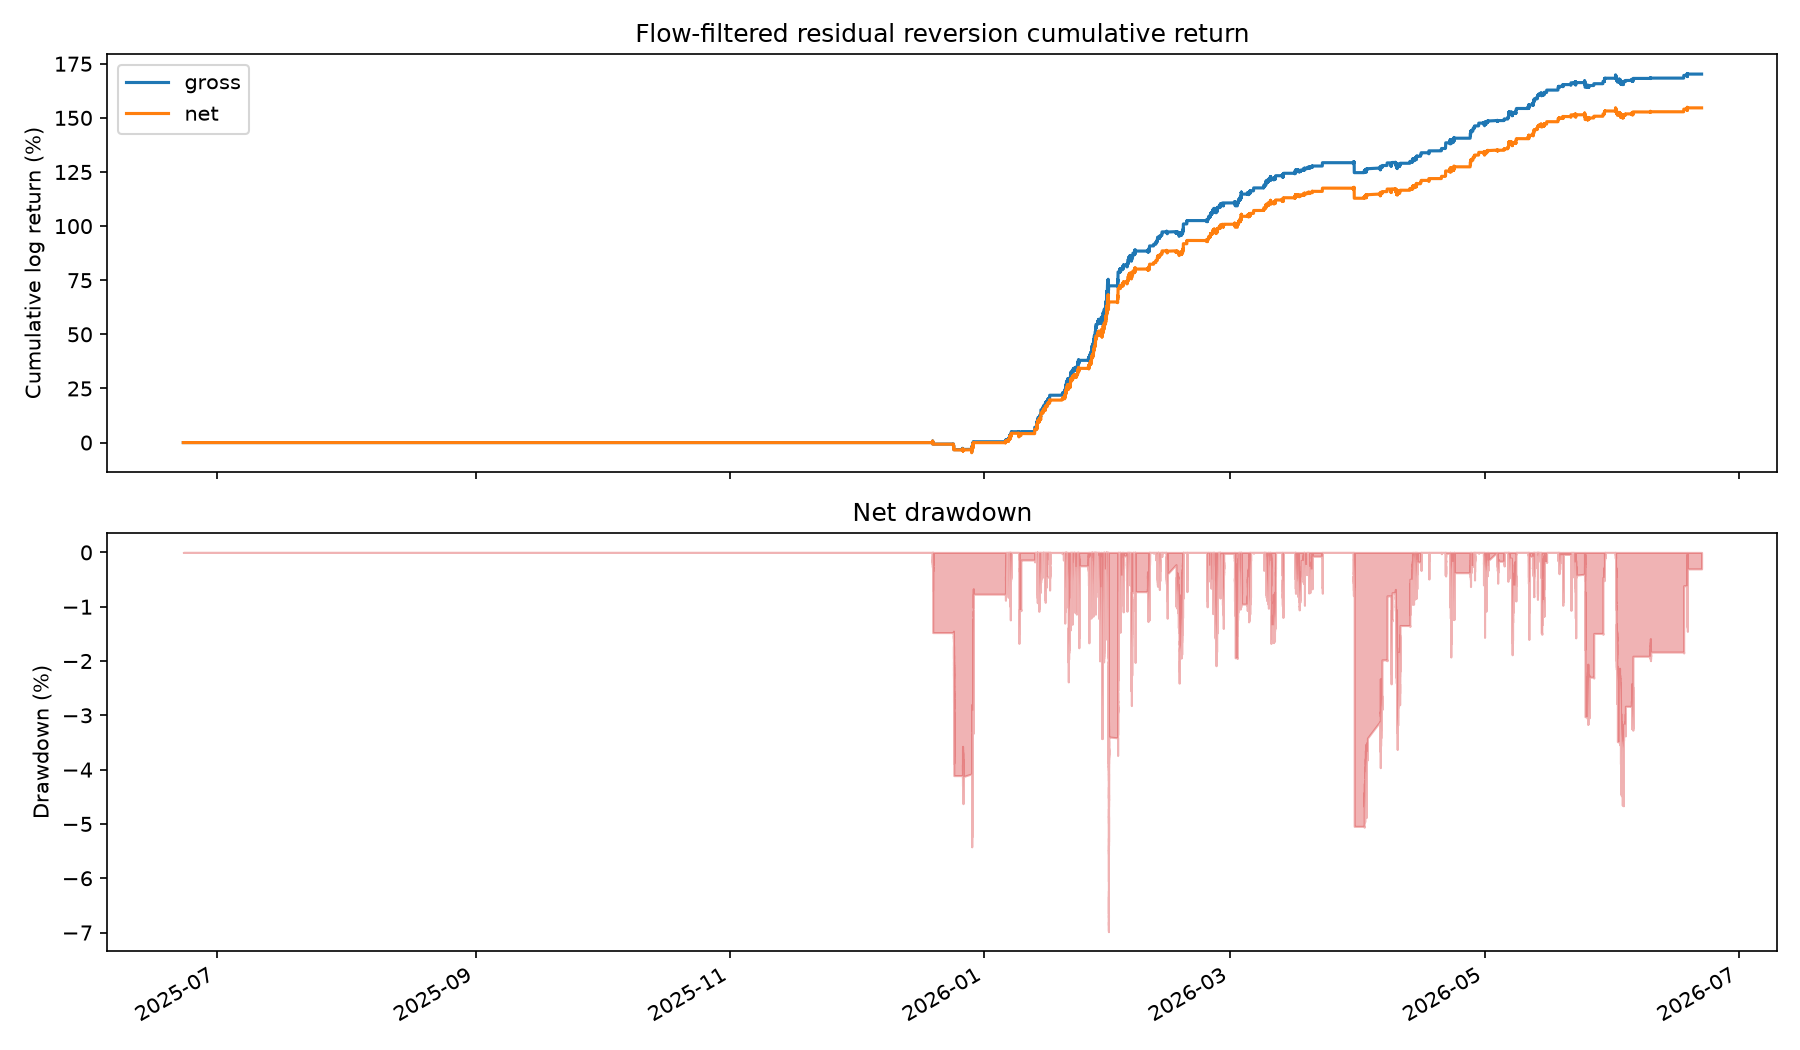

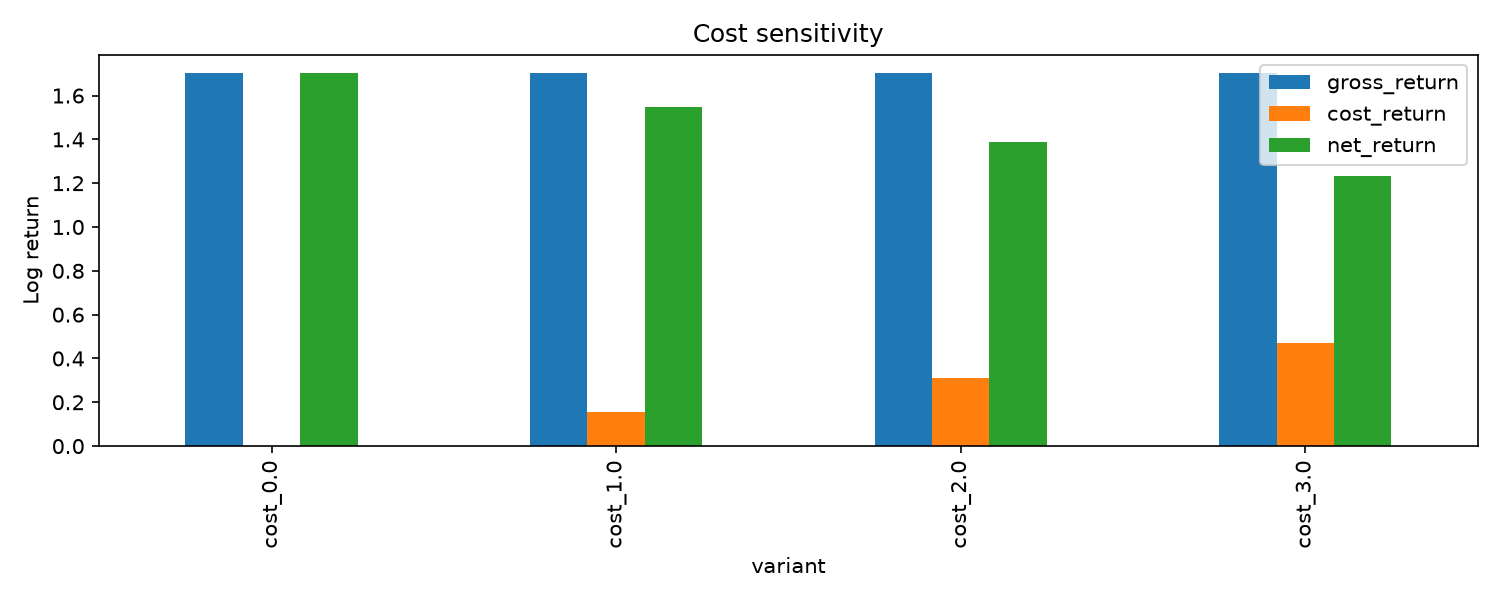

In [6]:
display(Image(filename=OUT / "plots/strategy_equity_drawdown.png"))
display(Image(filename=OUT / "plots/cost_sensitivity.png"))

In [7]:
pd.read_csv(OUT / "monthly_returns.csv")

,month,gross_return,cost_return,net_return,turnover,active_bars
0,2025-06,0.000000,0.000000,0.000000,0.000000,0
1,2025-07,0.000000,0.000000,0.000000,0.000000,0
2,2025-08,0.000000,0.000000,0.000000,0.000000,0
3,2025-09,0.000000,0.000000,0.000000,0.000000,0
4,2025-10,0.000000,0.000000,0.000000,0.000000,0
5,2025-11,0.000000,0.000000,0.000000,0.000000,0
6,2025-12,0.003838,0.004099,-0.000261,14.416667,537
7,2026-01,0.720246,0.070298,0.649948,298.833333,6750
8,2026-02,0.382833,0.024072,0.358760,103.625000,2545
9,2026-03,0.140046,0.019701,0.120344,78.833333,2908


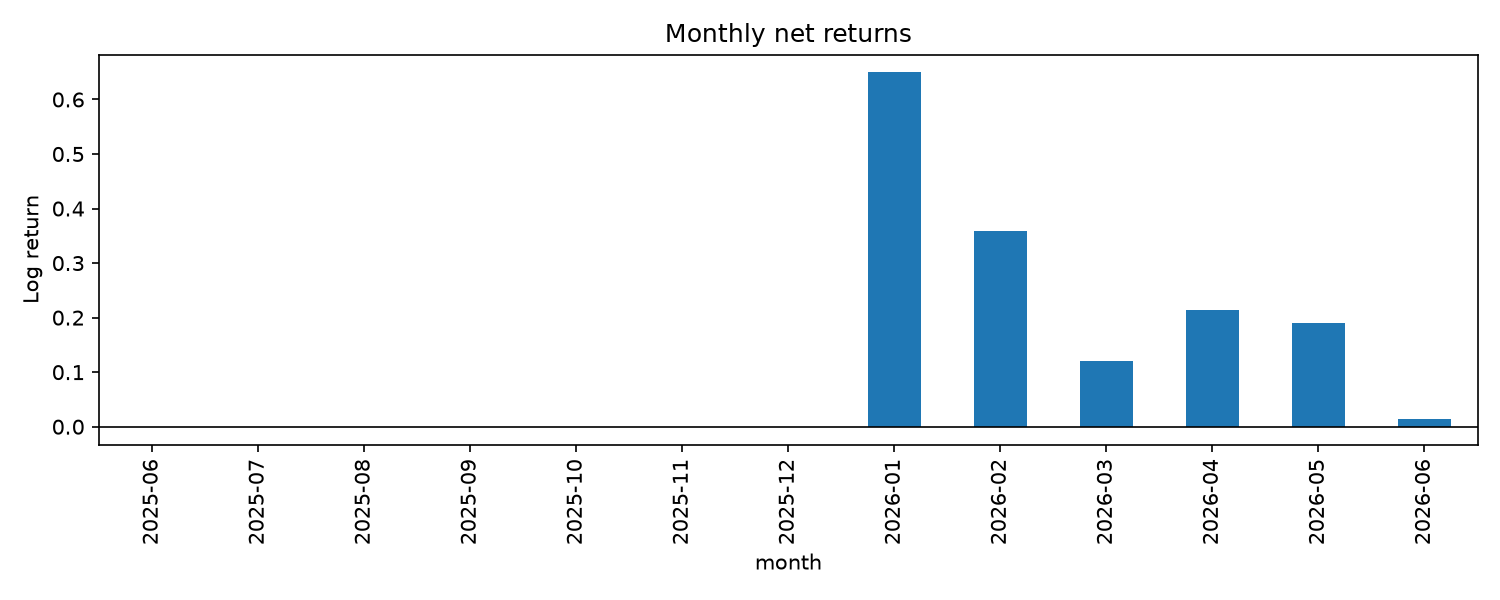

In [8]:
display(Image(filename=OUT / "plots/monthly_returns.png"))

## Exposure And State Filters

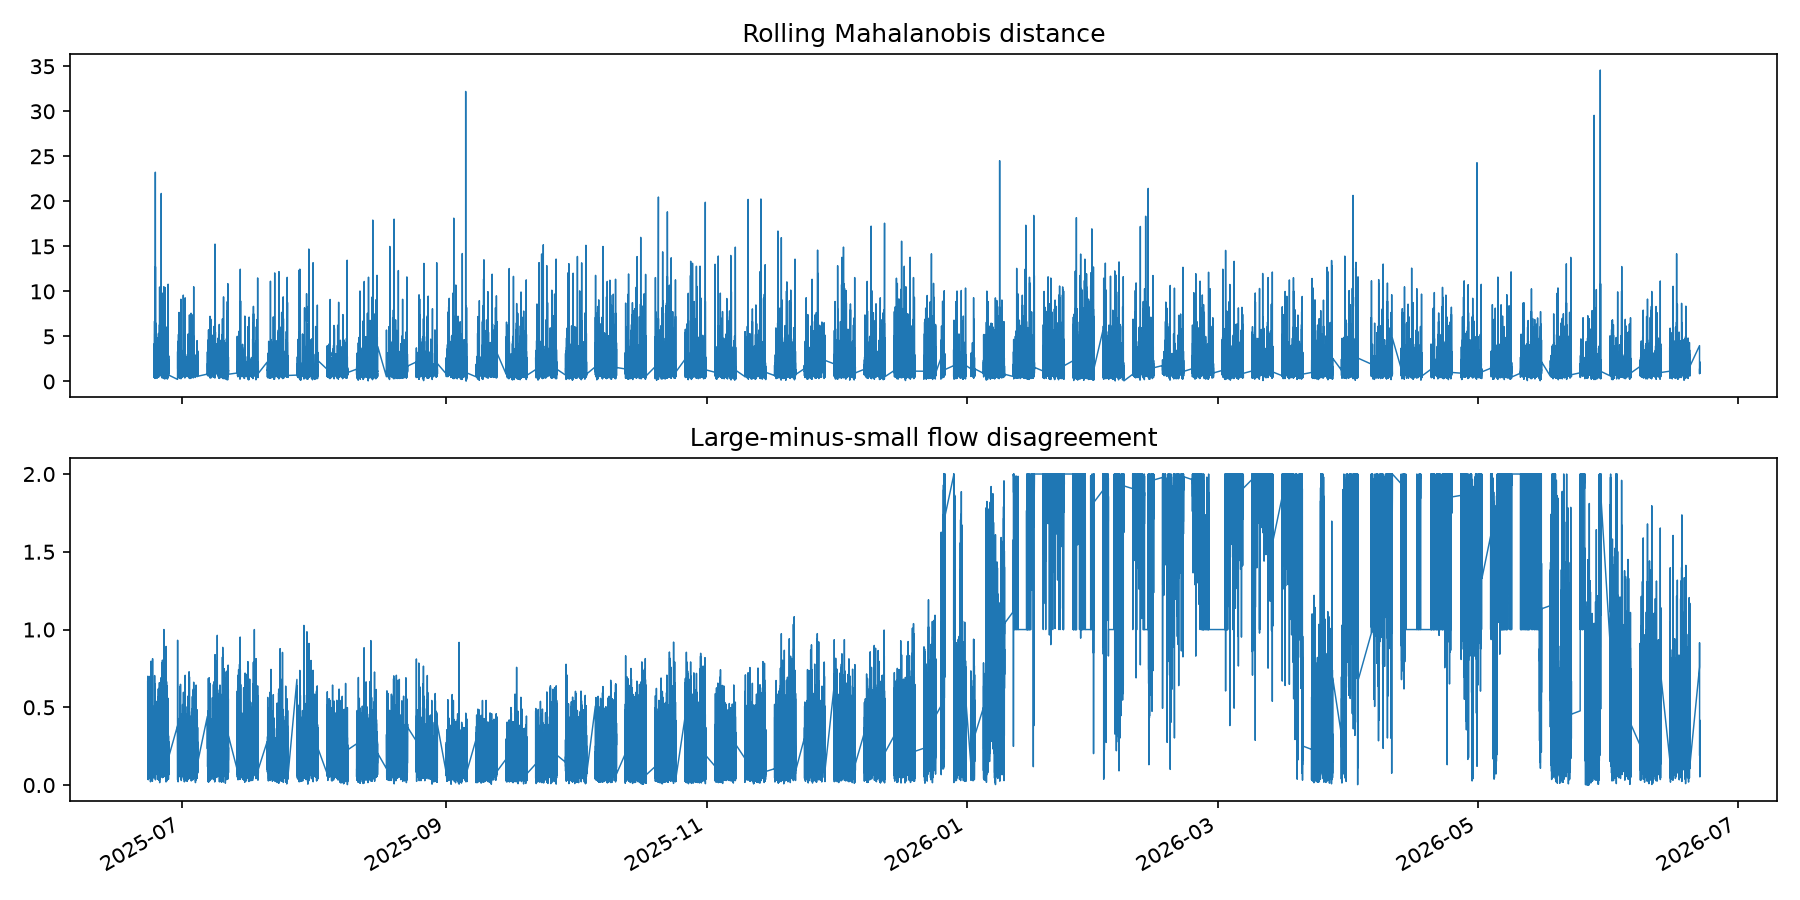

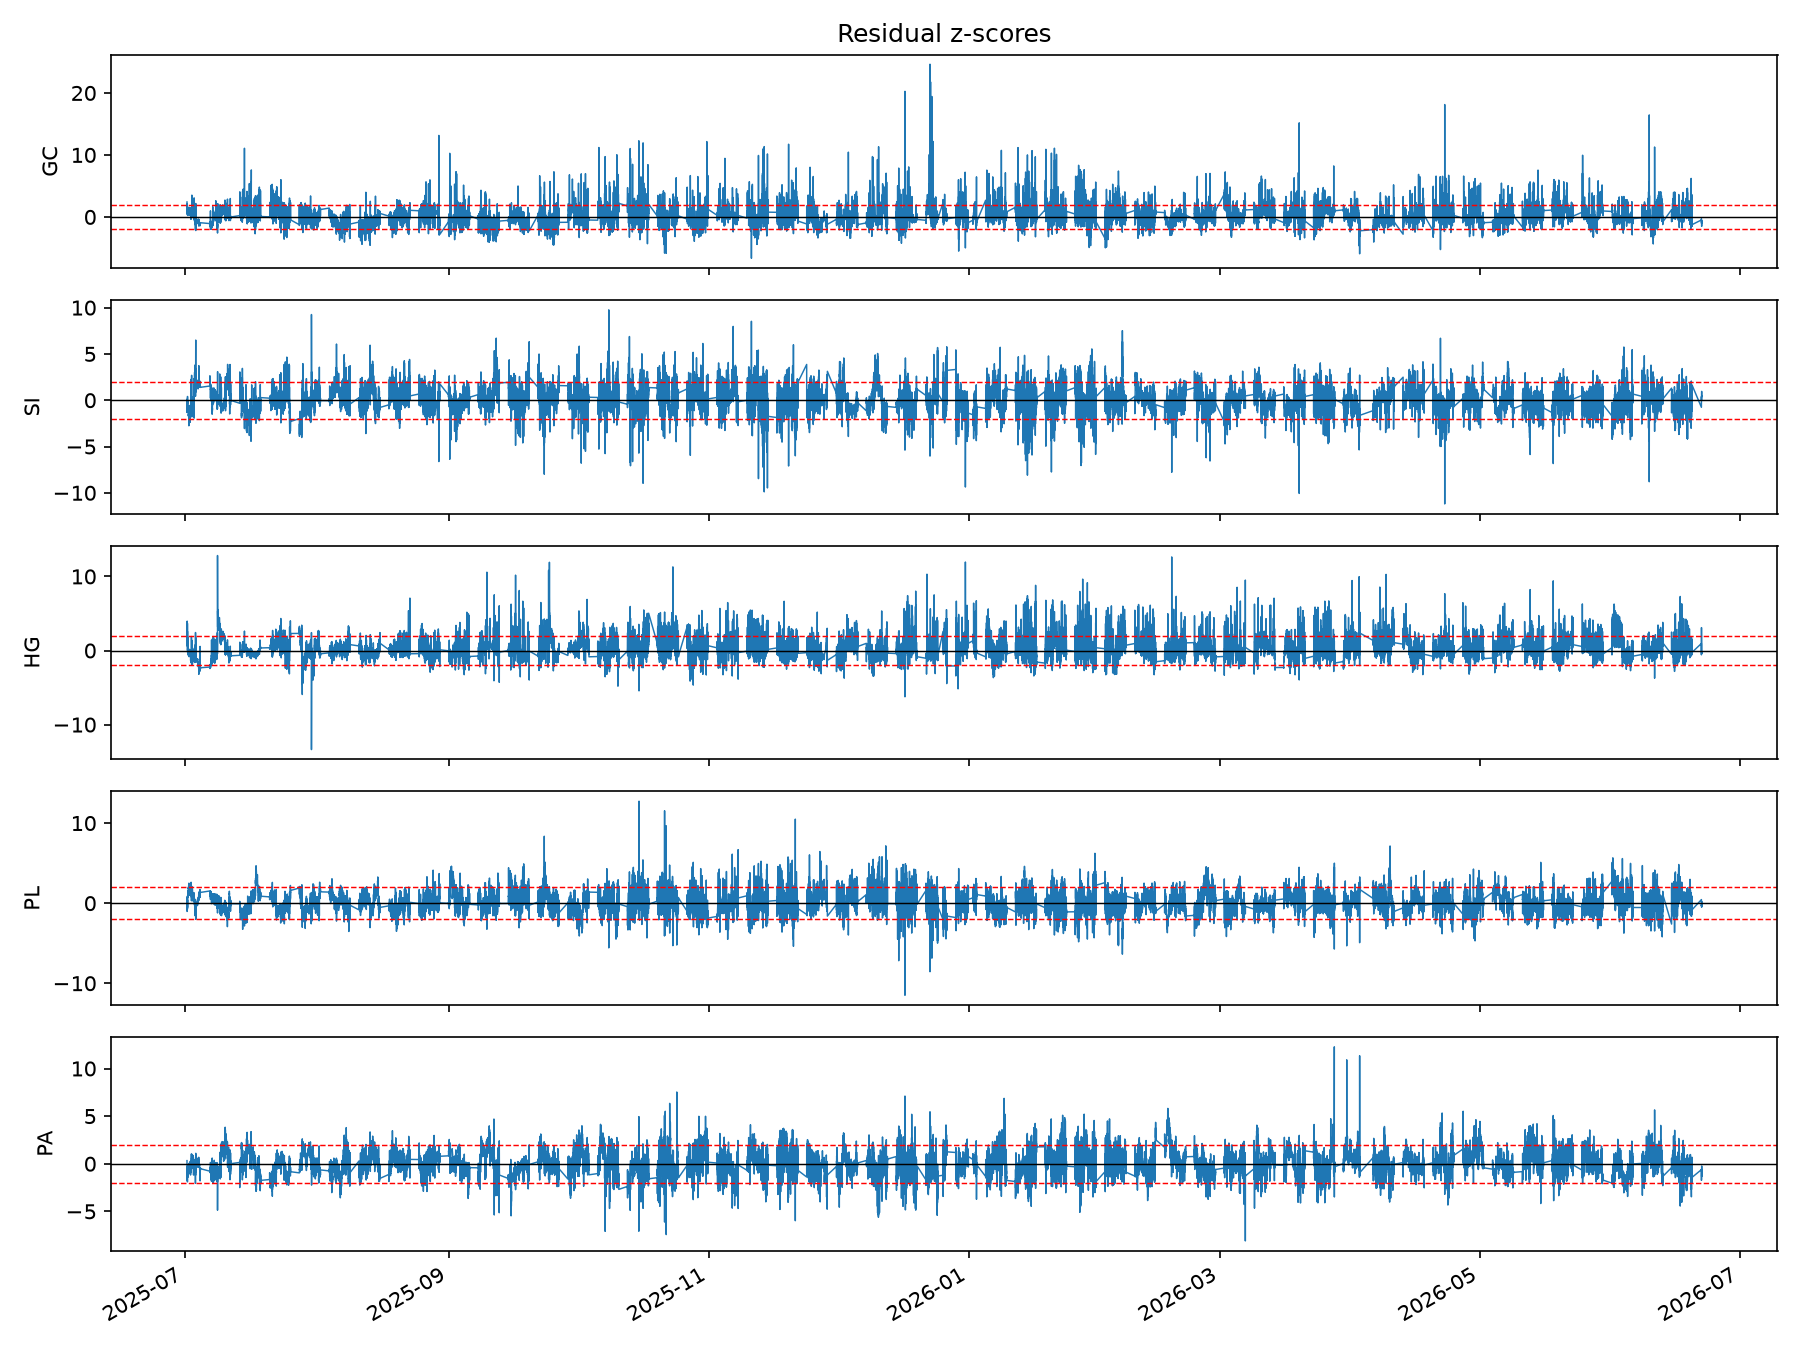

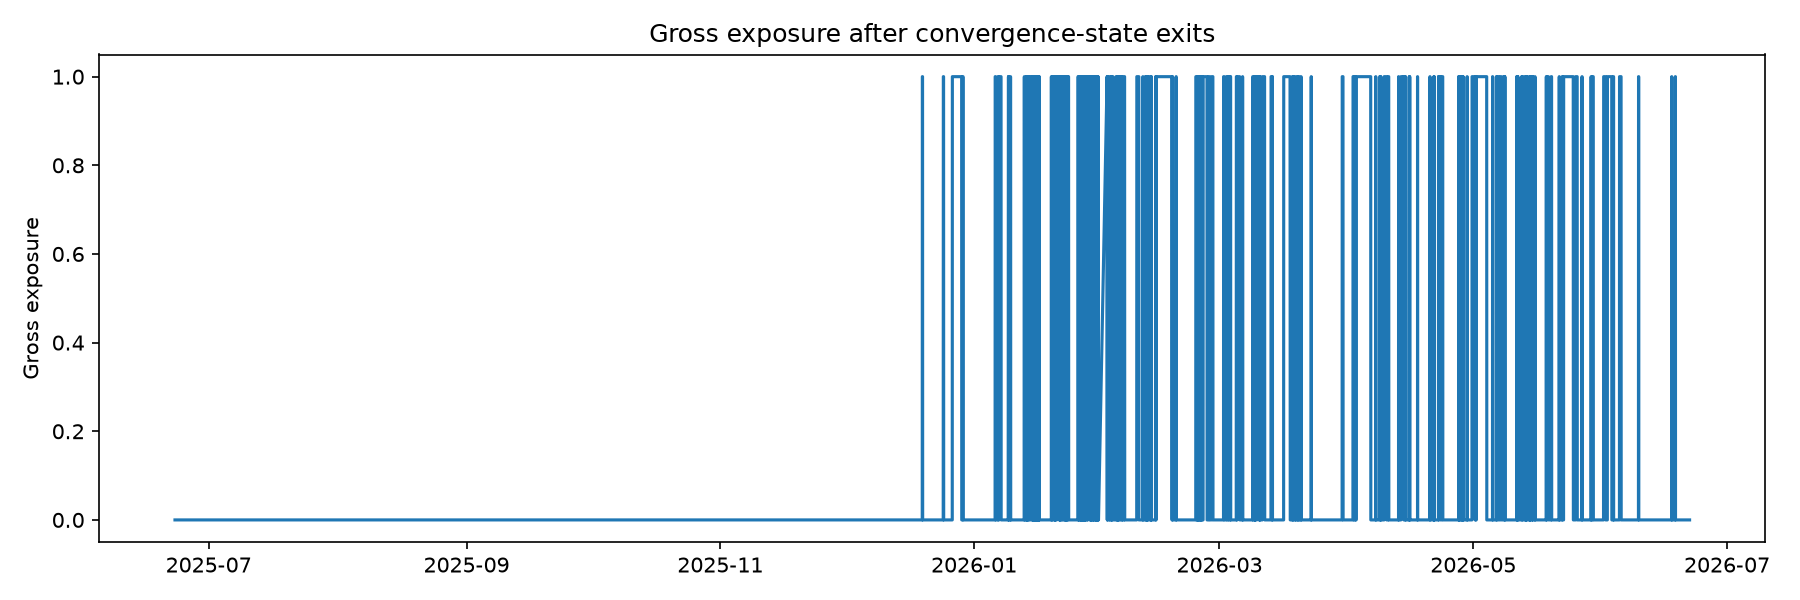

In [9]:
display(Image(filename=OUT / "plots/flow_filters.png"))
display(Image(filename=OUT / "plots/residual_zscores.png"))
display(Image(filename=OUT / "plots/gross_exposure.png"))

In [10]:
positions = pd.read_parquet(OUT / "positions.parquet")
positions.abs().sum(axis=1).describe().to_frame("gross_exposure")

,gross_exposure
count,115649.000000
mean,0.139327
std,0.346289
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


## Validation

In [11]:
pd.read_csv(OUT / "split_metrics.csv")

,split,observations,active_bars,gross_return,cost_return,net_return,mean_net_bps,tstat,annualized_sharpe,hit_rate,max_drawdown,gross_to_cost,turnover
0,train,80954,7925,0.862190,0.080140,0.782050,0.096604,4.219898,5.051832,0.051054,-0.069836,10.758524,341.500000
1,test_embargoed,34645,8188,0.840081,0.075974,0.764107,0.220553,3.541534,6.480928,0.119873,-0.050604,11.057539,331.708333


In [12]:
pd.read_csv(OUT / "bootstrap.csv")

,metric,observed,bootstrap_mean,p05,p50,p95,p_positive,days,iterations
0,net_return,1.546157,1.548901,1.173044,1.542043,1.956016,1.0,312,2000


In [13]:
ic = pd.read_csv(OUT / "ic_fdr.csv")
ic.assign(abs_ic=ic["spearman_ic"].abs()).sort_values("abs_ic", ascending=False).head(30)

,feature,root,horizon,spearman_ic,pvalue,observations,bh_qvalue,abs_ic
73,rv_z_HG,HG,2,-0.151953,0.000000e+00,113648,0.000000e+00,0.151953
72,rv_z_HG,HG,1,-0.151178,0.000000e+00,113649,0.000000e+00,0.151178
74,rv_z_HG,HG,5,-0.151116,0.000000e+00,113645,0.000000e+00,0.151116
75,rv_z_HG,HG,10,-0.149793,0.000000e+00,113640,0.000000e+00,0.149793
76,rv_z_HG,HG,20,-0.147136,0.000000e+00,113630,0.000000e+00,0.147136
77,rv_z_HG,HG,50,-0.129693,0.000000e+00,113600,0.000000e+00,0.129693
2,rv_z_GC,GC,5,-0.117519,0.000000e+00,113645,0.000000e+00,0.117519
3,rv_z_GC,GC,10,-0.117446,0.000000e+00,113640,0.000000e+00,0.117446
1,rv_z_GC,GC,2,-0.114240,0.000000e+00,113648,0.000000e+00,0.114240
4,rv_z_GC,GC,20,-0.113377,0.000000e+00,113630,0.000000e+00,0.113377


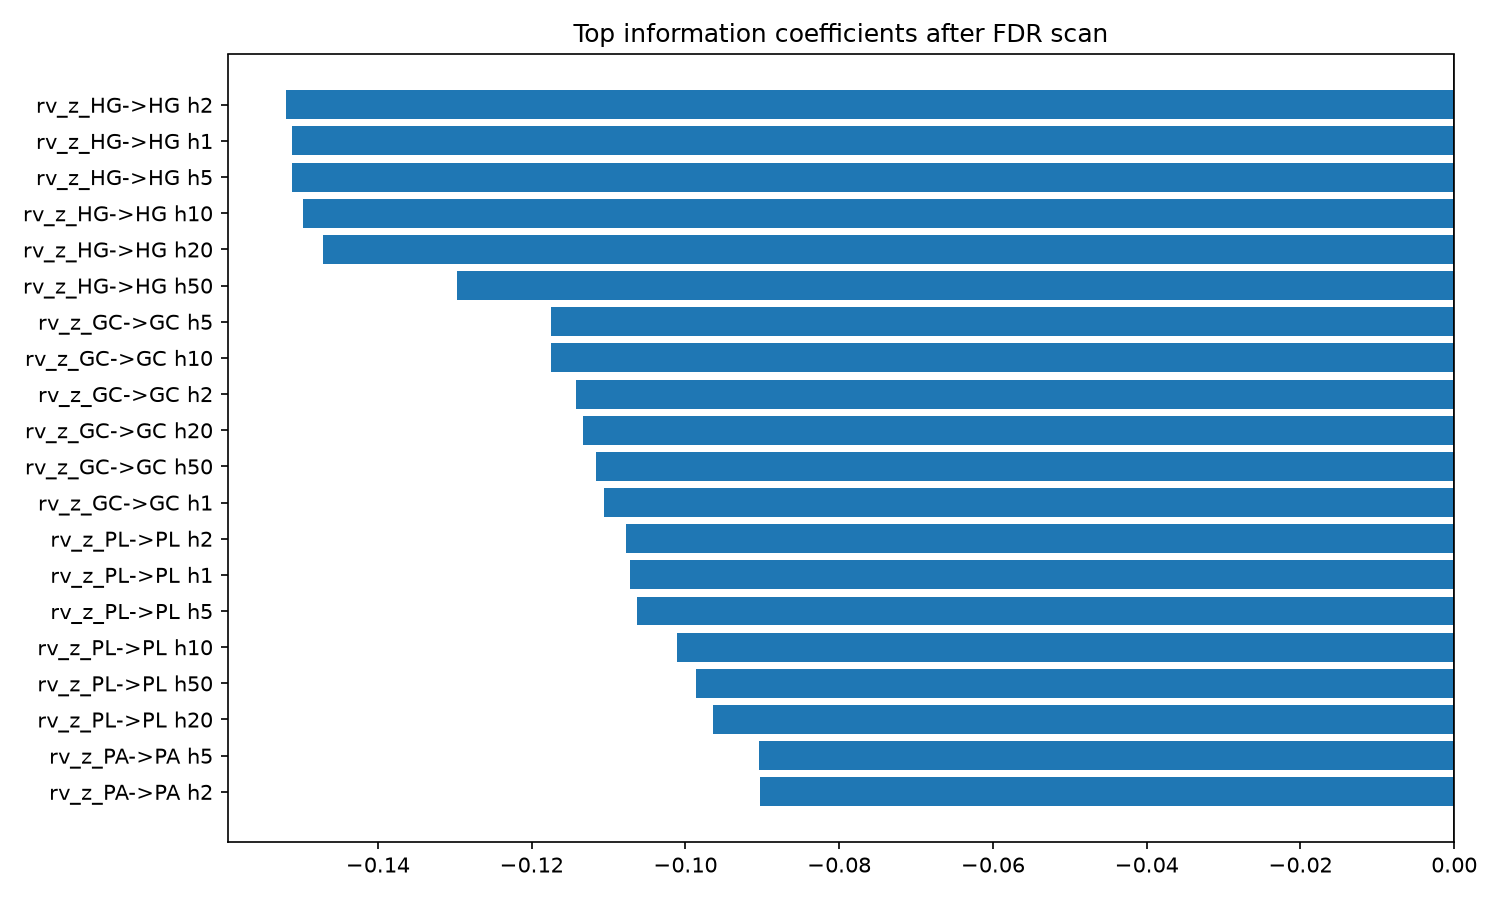

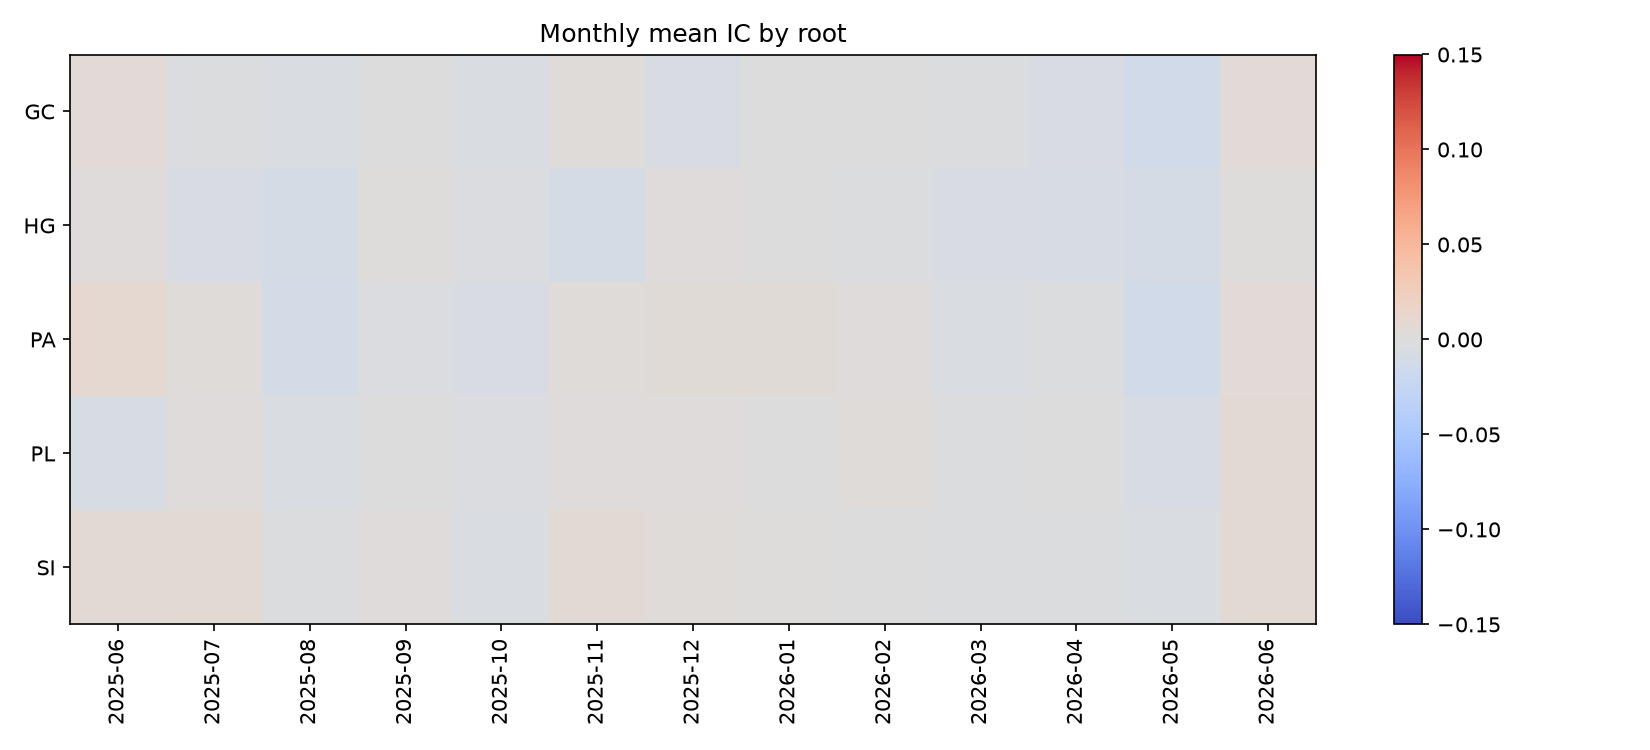

In [14]:
display(Image(filename=OUT / "plots/top_ic.png"))
display(Image(filename=OUT / "plots/monthly_ic_heatmap.png"))

In [15]:
monthly_ic = pd.read_csv(OUT / "monthly_ic.csv")
monthly_ic.groupby("root")["spearman_ic"].agg(["mean", "std", "count"])

,mean,std,count
root,,,
GC,-0.001787,0.037925,359
HG,-0.003581,0.042030,359
PA,-0.000669,0.034938,359
PL,-0.000511,0.036127,359
SI,0.001392,0.034422,359


## ALI Isolation

In [16]:
pd.read_csv(OUT / "ali_diagnostics.csv")

,root,trades,start_ts,end_ts,notional,signed_ratio,median_trade_notional,p99_trade_notional
0,ALI,112563,2025-06-23 00:10:43.178975+00:00,2026-06-21 23:50:52.149488+00:00,1.975728e+10,0.006048,81512.5,750437.5


## Interpretation

This run passes the initial research gate: the core liquid metals sleeve remains positive after MBP-1 spread-based costs, after 2x and 3x cost stress, and in the embargoed test split. The active trading period starts only after the fair-value warm-up, so early months are intentionally flat.

The strongest predictive features are still residual z-scores, especially `HG`, `GC`, and `PL`, and their IC signs are negative: high positive residuals predict lower future returns and high negative residuals predict higher future returns. That is relative-value convergence / mean reversion, not momentum.

The result should not be promoted to paper trading until tested on new forward data with stricter execution sizing, roll handling, and per-contract liquidity constraints.